### Introducere in Retele Neuronale Convolutionale (CNN)

Retelele neuronale convolutionale (CNN - Convolutional Neural Networks) reprezinta un tip specializat de retele neuronale artificiale, proiectate pentru procesarea datelor cu structura in grila, cum ar fi imaginile.

CNN-urile sunt eficiente in sarcini precum:
- Recunoasterea obiectelor in imagini
- Clasificarea imaginilor
- Detectarea trasaturilor vizuale relevante

Componente principale:
- **Straturi convolutionale (`Conv2D`)** – extrag automat trasaturi locale din imagini, cum ar fi margini, texturi sau forme.
- **Straturi de pooling (`MaxPooling2D`)** – reduc dimensiunea spatiala a datelor, pastrand informatia esentiala.
- **Straturi dense (`Dense`)** – realizeaza clasificarea pe baza trasaturilor extrase.

Avantaje:
- CNN-urile pot invata automat trasaturi relevante, fara a necesita inginerie manuala a caracteristicilor.
- Sunt mai eficiente decat retelele complet conectate pentru imagini.
- Ofera performante ridicate in sarcini de procesare vizuala.

In acest proiect vom folosi CNN-uri pentru clasificarea imaginilor in doua categorii: "dog" si "cat", explorand impactul adancimii retelei si al hiperparametrilor precum `kernel_size` si `optimizer`.


In [15]:
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

### Incarcarea datelor

In aceasta sectiune sunt incarcate datele de antrenare si testare din fisiere CSV. Seturile de date contin imaginile (ca vectori de pixeli) si etichetele asociate.

- `X_train`, `X_test` contin imaginile sub forma de matrice de valori numerice.
- `Y_train`, `Y_test` contin etichetele asociate fiecarei imagini (de exemplu, 0 pentru "dog", 1 pentru "cat").

Datele sunt separate in doua subseturi:
- **Train**: folosit pentru antrenarea modelelor.
- **Test**: folosit pentru evaluarea performantei modelelor pe date nevazute.


In [ ]:
X_train = np.loadtxt('../data/train/input.csv', delimiter=',')
Y_train = np.loadtxt('../data/train/labels.csv', delimiter=',')

X_test = np.loadtxt('../data/test/input_test.csv', delimiter=',')
Y_test = np.loadtxt('../data/test/labels_test.csv', delimiter=',')


### Preprocesarea datelor

Imaginile sunt reshape-uite pentru a avea forma corecta de intrare in retea: `(numar_imagini, 100, 100, 3)`, unde:
- `100 x 100` reprezinta dimensiunea fiecarei imagini
- `3` reprezinta cele trei canale de culoare (RGB)

Etichetele sunt reshape-uite pentru a avea forma `(numar_imagini, 1)`.

Apoi, valorile pixelilor sunt normalizate in intervalul `[0, 1]` prin impartirea la 255. Aceasta scalare ajuta la stabilizarea procesului de antrenare si accelereaza convergenta.


In [17]:

X_train = X_train.reshape(len(X_train), 100, 100, 3)
Y_train = Y_train.reshape(len(Y_train), 1)

X_test = X_test.reshape(len(X_test), 100, 100, 3)
Y_test = Y_test.reshape(len(Y_test), 1)

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


### Definirea modelului CNN cu 2 layere convolutionale

Aceasta functie construieste o retea neuronala convolutionala simpla, cu doua straturi convolutionale urmate de straturi dense.

Parametrii:
- `kernel_size`: specifica dimensiunea ferestrei de filtrare (ex: `(3, 3)` sau `(5, 5)`)
- `optimizer`: metoda de optimizare folosita pentru antrenare (ex: `'adam'` sau `'sgd'`)

Structura modelului:
1. `Conv2D(32)` - strat convolutional cu 32 de filtre
2. `MaxPooling2D` - reduce dimensiunea spatiala
3. `Conv2D(64)` - al doilea strat convolutional cu 64 de filtre
4. `MaxPooling2D`
5. `Flatten` - transforma output-ul 2D in vector 1D
6. `Dropout(0.3)` - reduce overfitting-ul
7. `Dense(128)` - strat dens complet conectat
8. `Dropout(0.3)`
9. `Dense(1, activation='sigmoid')` - strat de iesire pentru clasificare binara

Modelul este compilat cu functia de pierdere `binary_crossentropy` si metrul `accuracy`.


In [20]:
def build_model_2_layers(kernel_size, optimizer):
    model = Sequential([
        Conv2D(32, kernel_size=kernel_size, activation='relu', input_shape=(100, 100, 3)),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, kernel_size=kernel_size, activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

### Definirea modelului CNN cu 4 layere convolutionale

Aceasta functie construieste o retea neuronala convolutionala mai adanca, cu patru straturi convolutionale, destinata extragerii unor trasaturi mai complexe din imagini.

Parametrii:
- `kernel_size`: dimensiunea ferestrei de filtrare (de exemplu `(3, 3)` sau `(5, 5)`)
- `optimizer`: algoritmul de optimizare folosit pentru antrenare (ex: `'adam'`, `'sgd'`)

Structura modelului:
1. `Conv2D(32)` - strat initial cu 32 de filtre
2. `MaxPooling2D` - reduce dimensiunea spatiala
3. `Conv2D(64)` - al doilea strat convolutional
4. `MaxPooling2D`
5. `Conv2D(128)` - al treilea strat convolutional
6. `MaxPooling2D`
7. `Conv2D(256)` - al patrulea strat convolutional
8. `MaxPooling2D`
9. `Flatten` - transforma volumul 3D intr-un vector 1D
10. `Dropout(0.4)` - reduce overfitting-ul
11. `Dense(128)` - strat dens complet conectat
12. `Dropout(0.4)`
13. `Dense(1, activation='sigmoid')` - strat de iesire pentru clasificare binara

Modelul este compilat folosind functia de pierdere `binary_crossentropy` si metrul `accuracy`.


In [21]:
def build_model_4_layers(kernel_size, optimizer):
    model = Sequential([
        Conv2D(32, kernel_size=kernel_size, activation='relu', input_shape=(100, 100, 3)),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, kernel_size=kernel_size, activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(128, kernel_size=kernel_size, activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(256, kernel_size=kernel_size, activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

### Testarea combinatiilor de modele si hiperparametri

In aceasta sectiune sunt testate diferite combinatii de arhitecturi si hiperparametri pentru a evalua performanta modelelor CNN.

Sunt definite urmatoarele combinatii:
- Doua tipuri de retele: `'2_layers'` si `'4_layers'`
- Doua tipuri de optimizatori: `'adam'` si `'sgd'`
- Doua valori pentru dimensiunea kernelului: `(3, 3)` si `(5, 5)`

Pentru fiecare combinatie:
1. Se construieste modelul corespunzator.
2. Se antreneaza modelul pe datele de antrenare (`X_train`, `Y_train`) pentru 10 epoci.
3. Se fac predictii pe setul de testare (`X_test`).
4. Se calculeaza acuratetea pe setul de test folosind `accuracy_score`.
5. Rezultatele sunt salvate intr-o lista `results` pentru comparare ulterioara.

Aceasta abordare permite analizarea impactului adancimii retelei, dimensiunii kernelului si a optimizatorului asupra performantei clasificarii.


In [22]:
from sklearn.metrics import accuracy_score

results = []

optimizers = ['adam', 'sgd']
kernel_sizes = [(3, 3), (5, 5)]
model_types = ['2_layers', '4_layers']



for model_type in model_types:
    for opt in optimizers:
        for ksize in kernel_sizes:
            print(f"Testing {model_type} with optimizer={opt}, kernel_size={ksize}")
            
            if model_type == '2_layers':
                model = build_model_2_layers(kernel_size=ksize, optimizer=opt)
            else:
                model = build_model_4_layers(kernel_size=ksize, optimizer=opt)
            
            model.fit(X_train, Y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
            preds = (model.predict(X_test) > 0.5).astype("int32")
            
            acc = accuracy_score(Y_test, preds)
            results.append({
                'model': model_type,
                'optimizer': opt,
                'kernel_size': ksize,
                'accuracy': acc
            })



Testing 2_layers with optimizer=adam, kernel_size=(3, 3)
13/13 [==============================] - 1s 46ms/step
Testing 2_layers with optimizer=adam, kernel_size=(5, 5)
13/13 [==============================] - 1s 56ms/step
Testing 2_layers with optimizer=sgd, kernel_size=(3, 3)
13/13 [==============================] - 1s 41ms/step
Testing 2_layers with optimizer=sgd, kernel_size=(5, 5)
13/13 [==============================] - 1s 57ms/step
Testing 4_layers with optimizer=adam, kernel_size=(3, 3)
13/13 [==============================] - 1s 51ms/step
Testing 4_layers with optimizer=adam, kernel_size=(5, 5)
13/13 [==============================] - 1s 68ms/step
Testing 4_layers with optimizer=sgd, kernel_size=(3, 3)
13/13 [==============================] - 1s 52ms/step
Testing 4_layers with optimizer=sgd, kernel_size=(5, 5)
13/13 [==============================] - 1s 68ms/step


### Afisarea rezultatelor

Rezultatele obtinute din testarea combinatiilor de modele si hiperparametri sunt organizate intr-un DataFrame Pandas pentru o analiza mai usoara.

Pasii efectuati:
1. Se converteste lista `results` intr-un `DataFrame` Pandas.
2. Se sorteaza in functie de acuratete (`accuracy`) in ordine descrescatoare.
3. Se afiseaza rezultatele pentru a identifica cea mai buna combinatie de arhitectura, kernel si optimizator.

Aceasta afisare permite compararea directa a performantelor si alegerea configuratiei optime pentru clasificarea imaginilor.


In [24]:
import pandas as pd
df_results = pd.DataFrame(results)
df_results.sort_values(by='accuracy', ascending=False, inplace=True)
print(df_results)


      model optimizer kernel_size  accuracy
1  2_layers      adam      (5, 5)    0.6825
0  2_layers      adam      (3, 3)    0.6650
4  4_layers      adam      (3, 3)    0.6200
5  4_layers      adam      (5, 5)    0.5700
3  2_layers       sgd      (5, 5)    0.5300
2  2_layers       sgd      (3, 3)    0.5175
6  4_layers       sgd      (3, 3)    0.5000
7  4_layers       sgd      (5, 5)    0.5000


### Testarea vizuala a predictiilor pentru imagini random

Aceasta functie permite testarea unui model CNN pe o imagine aleatoare din setul de testare, oferind o verificare vizuala a performantei modelului.

Pasii urmati:
1. Se selecteaza o imagine random din `X_test`.
2. Se afiseaza imaginea folosind `matplotlib`.
3. Se face o predictie folosind modelul dat.
4. Se afiseaza eticheta prezisa, scorul de incredere si, optional, eticheta reala daca este disponibila (`Y_test`).

Functia `test_random_image` este apelata de doua ori:
- O data cu modelul cu 2 layere convolutionale si kernel de dimensiune 3, antrenat cu `adam`.
- O data cu modelul cu 4 layere convolutionale cu aceiasi parametri.

Aceasta comparatie vizuala permite observarea directa a modului in care fiecare model clasifica imagini individuale.


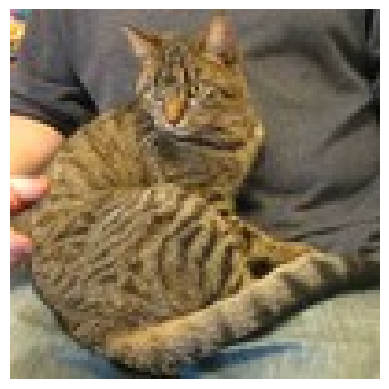

1/1 [==============================] - 0s 154ms/step
Predicted: cat (score=0.55)
Actual: cat


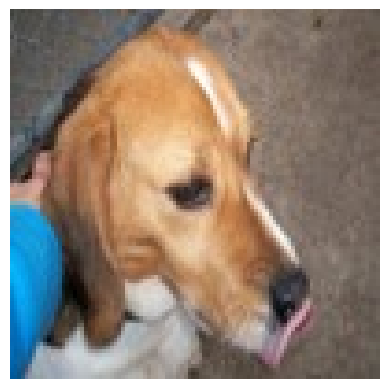

1/1 [==============================] - 0s 131ms/step
Predicted: dog (score=0.47)
Actual: dog


In [32]:
def test_random_image(model, X_test, Y_test=None, label_map={0: 'dog', 1: 'cat'}):
    import random
    import matplotlib.pyplot as plt

    idx = random.randint(0, len(X_test) - 1)
    
    plt.imshow((X_test[idx] * 255).astype(np.uint8))
    plt.axis('off')
    plt.show()
    
    y_pred = model.predict(X_test[idx].reshape(1, 100, 100, 3))[0][0]
    pred_label = label_map[int(y_pred > 0.5)]

    print(f"Predicted: {pred_label} (score={y_pred:.2f})")
    
    if Y_test is not None:
        true_label = label_map[int(Y_test[idx][0])]
        print(f"Actual: {true_label}")


test_random_image(build_model_2_layers(3, "adam"), X_test, Y_test)

test_random_image(build_model_4_layers(3, "adam"), X_test, Y_test)

